# Исследование рынка заведений общественного питания Москвы

### Цели и задачи проекта

**Цель** - провести исследовательский анализ рынка заведений общественного питания Москвы для выявления особенностей рынка и подготовки рекомендаций инвесторам по выбору формата будущего заведения.

**Задачи:**
* Подготовить данные для проведения анализа рынка общественного питания Москвы.
* Исследовать распределение заведений по категориям и районам Москвы.
* Проанализировать соотношение сетевых и несетевых заведений.
* Изучить количество посадочных мест в заведениях различных категорий.
* Исследовать рейтинги заведений и факторы, влияющие на них.
* Определить наиболее популярные сети общественного питания Москвы.
* Проанализировать вариацию среднего чека в зависимости от района расположения заведения.
* Выявить наиболее привлекательные форматы и локации для открытия нового заведения.
* Подготовить рекомендации для инвесторов по выбору формата и местоположения будущего бизнеса.

### Описание данных

- `rest_info.csv` — информация о заведениях общественного питания: расположение, категория, рейтинг, режим работы, сетевой статус и количество посадочных мест.
- `rest_price.csv` — информация о ценовом уровне заведений и стоимости среднего чека и отдельных позиций.

### Содержимое проекта
1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации
---

## 1. Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем данные '/datasets/rest_info.csv'
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')

In [3]:
# Загружаем данные '/datasets/rest_price.csv'
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [4]:
# Выводим 5 строк датасета rest_info
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим 5 строк датасета rest_price
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датасете '/datasets/rest_info.csv'
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [7]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

**В датафрейме `rest_info`** содержится 8406 строк и 9 столбцов.

Структура данных соответствует описанию проекта.

Типы данных:

* `float64` — 2 столбца;
* `int64` — 1 столбец;
* `object` — 6 столбцов.

Обнаружены пропуски:

* `hours` — 536 значений;
* `seats` — 3611 значений.

Столбец `seats` целесообразно перевести из типа `float64` в `Int64`, так как он содержит количество посадочных мест, которое не может быть дробным значением.

**В датафрейме `rest_price`** содержится 4058 строк и 5 столбцов.

Типы данных:

* `object` — 3 столбца;
* `float64` — 2 столбца.

Типы данных соответствуют содержимому столбцов и не требуют дополнительного преобразования.

Обнаружены пропуски:

* `price` — 743 значения;
* `avg_bill` — 242 значения;
* `middle_avg_bill` — 909 значений;
* `middle_coffee_cup` — 3523 значения.


### Подготовка единого датафрейма


In [8]:
# Объединяем 2 датасета по столбцу 'id',  через 'left'
df = rest_info.merge(rest_price, on = 'id', how = 'left')

In [9]:
# Выводим датафрейм 'rest_info_price'
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Выводим информацию о дотафрейме 'rest_info_price'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


## 2. Предобработка данных


In [11]:
# В столбце 'seats' переводим тип данных в 'Int64'
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')

In [12]:
# Проверяем тип данных в столбце 'seats'
df['seats'].dtype

dtype('float64')

In [13]:
# Определяем количество,долю и тип данных пропущеных значений в столбцах датафрейма 'df'
missing_table = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().mean() * 100).round(2),
    'Тип данных': df.dtypes
})
missing_table

,Количество пропусков,Доля пропусков (%),Тип данных
id,0,0.00,object
name,0,0.00,object
category,0,0.00,object
address,0,0.00,object
district,0,0.00,object
hours,536,6.38,object
rating,0,0.00,float64
chain,0,0.00,int64
seats,3611,42.96,float64
price,5091,60.56,object


In [14]:
# Заменяем пропуски в столбцах 'hours', 'price','avg_bill' на 'нет данных'
for culumn in ['hours', 'price','avg_bill']:
    df[culumn] = df[culumn].fillna('нет данных') 

In [15]:
# Прверяем результат по исправленым пропускам в датафрейме 'df'
missing_table = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков (%)': (df.isnull().mean() * 100).round(2),
    'Тип данных': df.dtypes
})
missing_table

,Количество пропусков,Доля пропусков (%),Тип данных
id,0,0.00,object
name,0,0.00,object
category,0,0.00,object
address,0,0.00,object
district,0,0.00,object
hours,0,0.00,object
rating,0,0.00,float64
chain,0,0.00,int64
seats,3611,42.96,float64
price,0,0.00,object


**Вывод по пропускам**

В ходе анализа пропущенных значений было установлено, что часть пропусков связана с отсутствием текстовой информации о режиме работы, ценовой категории и среднем чеке заведения. В столбцах `hours`, `price` и `avg_bill` такие пропуски были заменены на значение «Нет данных».

В столбцах `seats`, `middle_avg_bill` и `middle_coffee_cup` пропуски решено оставить без изменений. Для seats корректное восстановление значений невозможно без искажения результатов анализа. Для `middle_avg_bil`l и `middle_coffee_cup` пропуски являются закономерными и связаны с особенностями формирования данных, поэтому не требуют дополнительной обработки.

In [16]:
# Выводим уникальные значения столбцов 'category', 'district', 'price'
for column in ['category', 'district', 'price']:
    print(f'Столбец {column}:')
    print()
    print(df[column].unique())
    print()

Столбец category:

['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']

Столбец district:

['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']

Столбец price:

['нет данных' 'выше среднего' 'средние' 'высокие' 'низкие']



**Вывод по столбцам 'category', 'district', 'price'**

Неявных дубликатов не обнаружено. Значения записаны единообразно, опечаток, различий в регистре и альтернативных вариантов написания не выявлено.

In [17]:
# Выводим общее количество строк в df
df.shape[0]

8406

In [18]:
# Выводим количество уникальных значений из столбцов 'name','address'
for column in ['name','address']:
    print(f'Столбец {column}:')
    print()
    print(df[column].nunique())
    print()

Столбец name:

5614

Столбец address:

5753



In [19]:
# Приводим к нижнему регистру и убираем пробелы в столбцах 'name','address'
for column in ['name','address']:
    df[column] = df[column].str.lower().str.strip()

In [20]:
# Выводим результат уникальных значений столбцов 'name','address'
for column in ['name','address']:
    print(f'Столбец {column}:')
    print()
    print(df[column].nunique())
    print()

Столбец name:

5512

Столбец address:

5752



In [21]:
# Проверяем наличие количества дубликатов в столбцах 'name', 'address'
df.duplicated(subset=['name', 'address']).sum()

np.int64(4)

In [22]:
# Выводим дубликаты на экран
df[df.duplicated(subset = ['name', 'address'], keep = False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,нет данных,нет данных,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,нет данных,нет данных,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,нет данных,нет данных,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,нет данных,нет данных,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,нет данных,нет данных,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,нет данных,нет данных,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,нет данных,нет данных,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,нет данных,4.1,0,276.0,нет данных,нет данных,NaN,NaN


**Вывод по обнаруженым дубликатам столбцов 'name', 'address'**

После нормализации текстовых данных было обнаружено 4 случая совпадения названия и адреса заведения. Дополнительная проверка показала различия в таких признаках, как режим работы, категория заведения и сетевой статус. В связи с этим данные записи не были удалены, так как невозможно однозначно утверждать, что они являются ошибочными дубликатами.

In [23]:
# Поиск явных дубликатов в датафрейме 'df'
df.duplicated().sum()

np.int64(0)

**Вывод по явным дубликатам датафрема 'df '**

Проверка данных на явные дубликаты показала, что полностью совпадающие строки в датасете отсутствуют. Следовательно, удаление записей по причине наличия явных дубликатов не требуется.

In [24]:
# Создаем столбец 'is_24_7' с логическим выражением True и False, если зведения работают ежедневно и круглосуточно.
df['is_24_7'] = df['hours'].str.lower()==('ежедневно, круглосуточно')

In [25]:
# Выводим результат
df[['hours', 'is_24_7']]

,hours,is_24_7
0,"ежедневно, 10:00–22:00",False
1,"ежедневно, 10:00–22:00",False
2,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,"ежедневно, 09:00–22:00",False
4,"ежедневно, 10:00–22:00",False
...,...,...
8401,"ежедневно, 09:00–02:00",False
8402,"ежедневно, 08:00–22:00",False
8403,"ежедневно, круглосуточно",True
8404,"ежедневно, круглосуточно",True


In [26]:
# Выводим весь датафрейм
df

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,нет данных,нет данных,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,нет данных,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,суши мания,кафе,"москва, профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0,нет данных,нет данных,NaN,NaN,False
8402,ee6bb7c3650e47bd8186fca08eda1091,миславнес,кафе,"москва, пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0,нет данных,нет данных,NaN,NaN,False
8403,62e8c64d4c89467aba608e39ef87616b,самовар,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0,нет данных,Средний счёт:от 150 ₽,150.0,NaN,True
8404,06a0db5ecd4842d48cd6350aa923e297,чайхана sabr,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0,нет данных,нет данных,NaN,NaN,True


---

### Промежуточный вывод


В ходе предобработки данные были объединены в единый датафрейм по столбцу `id`.

Был проведён анализ типов данных. Столбец `seats` был преобразован из типа `float64` в `Int64`, так как содержит количество посадочных мест, которое должно быть представлено целыми числами. Остальные типы данных были признаны корректными и не изменялись.

Проведён анализ пропущенных значений. В столбце `hours` 536 пропусков (6,38%) были заменены на значение «нет данных», поскольку восстановить информацию о режиме работы невозможно. В столбце `seats` 3611 пропусков (42,96%) оставлены без изменений, так как корректно восстановить количество посадочных мест невозможно без искажения данных. В столбцах `price` (60,56%) и `avg_bill` (54,60%) пропуски были заменены на значение «нет данных». В столбцах `middle_avg_bill` (62,54%) и `middle_coffee_cup` (93,64%) пропуски оставлены без изменений, поскольку они связаны с особенностями формирования данных и не являются ошибками.

Для поиска неявных дубликатов были проанализированы текстовые столбцы `category`, `district`, `price`, `name` и `address`. В столбцах `name` и `address` данные были нормализованы путём приведения текста к нижнему регистру и удаления лишних пробелов. В результате были выявлены различные варианты написания одних и тех же названий заведений. Проверка показала отсутствие явных дубликатов в датасете. Также были обнаружены 4 совпадения по сочетанию полей `name` и `address`, однако данные записи содержали различия в характеристиках заведений и были сохранены.

Для дальнейшего анализа был создан новый логический признак `is_24_7`, который принимает значение `True` для заведений, работающих ежедневно и круглосуточно, и `False` для остальных заведений.

Удаление строк в ходе предобработки не выполнялось, поэтому объём данных остался без изменений и составляет 8406 записей.


## 3. Исследовательский анализ данных


In [27]:
# Распределяем категории по их количеству 
df['category'].value_counts()

category
кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

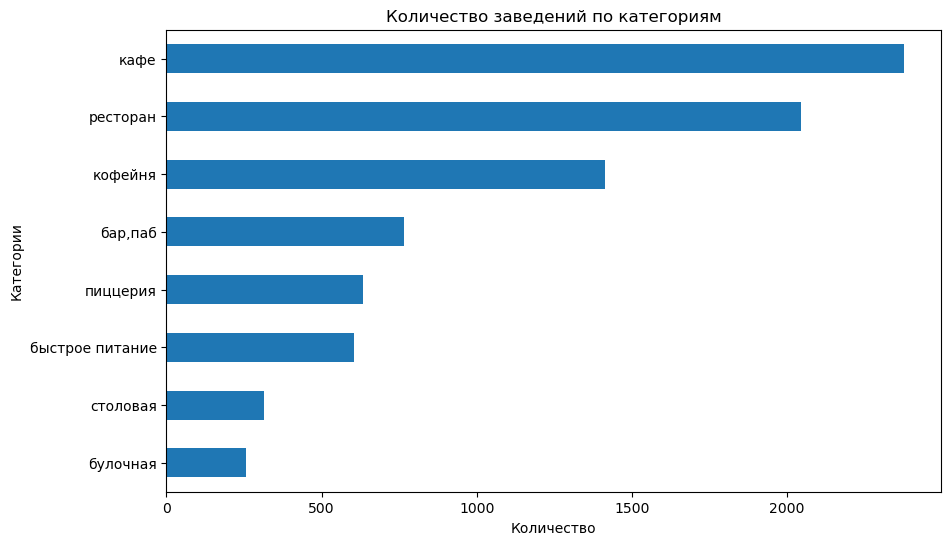

In [28]:
plt.figure(figsize=(10, 6))

df['category'].value_counts().sort_values(ascending=True).plot(kind = 'barh')
                                                                    
plt.title('Количество заведений по категориям')
plt.ylabel('Категории')
plt.xlabel('Количество')
plt.show()

**Вывод по количеству заведений по категориям**

В данных представлены 8 категорий заведений общественного питания.

Наиболее распространены кафе (2378), рестораны (2043) и кофейни (1413). 

Меньше всего представлено булочных (256) и столовых (315). 

Таким образом, основу рынка общественного питания Москвы составляют кафе, рестораны и кофейни.

In [29]:
# Распределение количества заведений по административным районам Москвы
df['district'].value_counts()

district
Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

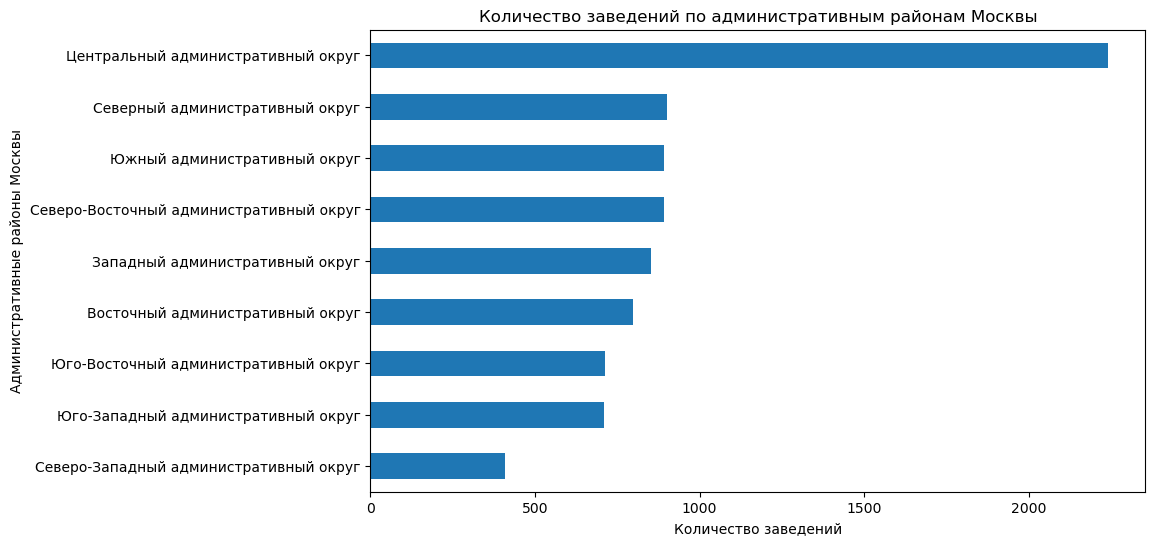

In [30]:
# Создаем визуализацию 'Распределение количества заведений по административным районам Москвы'
plt.figure(figsize=(10, 6))

df['district'].value_counts().sort_values(ascending=True).plot(kind = 'barh')

plt.title('Количество заведений по административным районам Москвы')
plt.ylabel('Административные районы Москвы')
plt.xlabel('Количество заведений')
plt.show()

In [31]:
# Распределение заведений каждой категории в Центральном административном округе Москвы
df_center = df.loc[df['district']== 'Центральный административный округ']

df_center['category'].value_counts()

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

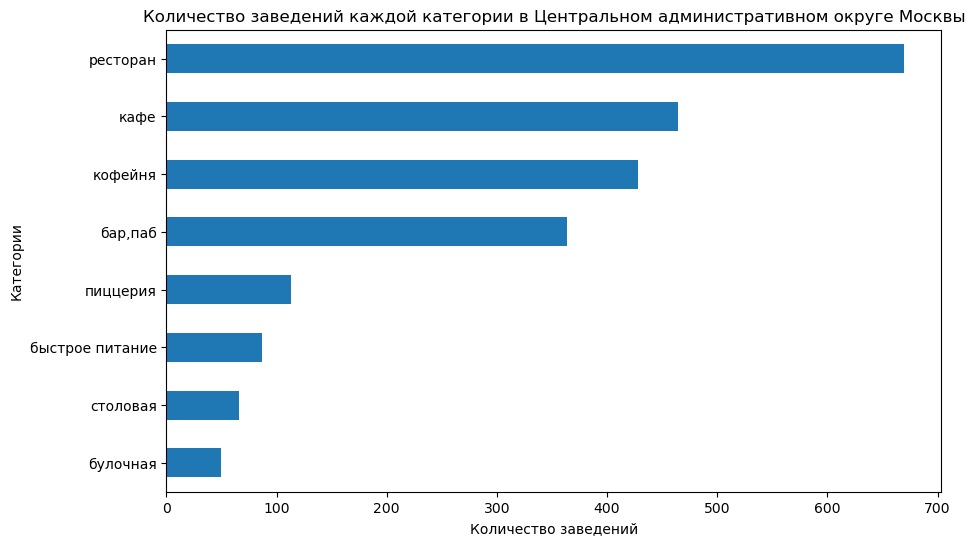

In [32]:
# Создаем визуализацию 'Распределение заведений каждой категории в Центральном административном округе Москвы'
plt.figure(figsize=(10, 6))

df_center['category'].value_counts().sort_values(ascending=True).plot(kind = 'barh')

plt.title('Количество заведений каждой категории в Центральном административном округе Москвы')
plt.ylabel('Категории')
plt.xlabel('Количество заведений')
plt.show()

**Вывод по распределение количества заведений по административным районам Москвы**

Наибольшее количество заведений общественного питания расположено в Центральном административном округе (2242 объекта), что значительно превышает показатели остальных округов. Наименьшее количество заведений представлено в Северо-Западном административном округе (409 объектов).

**Вывод по распределение заведений каждой категории в Центральном административном округе Москвы**

В Центральном административном округе наиболее распространены рестораны (670), кафе (464) и кофейни (428). Меньше всего представлены булочные (50) и столовые (66). Таким образом, в ЦАО преобладают заведения, ориентированные на посещение и досуг, тогда как остальные категории встречаются заметно реже.

In [33]:
# Создаем сводную таблицу по категориям и 'несетевой и сетевой'
pivot_chain = pd.pivot_table(df, index = 'category', columns = 'chain', values = 'id', aggfunc = 'count')

pivot_chain = pivot_chain.rename(columns = {0: 'несетевой', 1: 'сетевой'})

pivot_chain['доля несетевых %'] = round(pivot_chain['несетевой']/(pivot_chain['несетевой'] + pivot_chain['сетевой']), 2)*100
pivot_chain['доля сетевых %'] = round(pivot_chain['сетевой']/(pivot_chain['несетевой'] + pivot_chain['сетевой']), 2)*100

print(pivot_chain)
print()
print(f'Общее количество несетевых: {pivot_chain["несетевой"].sum()}')
print(f'Общее количество сетевых: {pivot_chain["сетевой"].sum()}')

chain            несетевой  сетевой  доля несетевых %  доля сетевых %
category                                                             
бар,паб                596      169              78.0            22.0
булочная                99      157              39.0            61.0
быстрое питание        371      232              62.0            38.0
кафе                  1599      779              67.0            33.0
кофейня                693      720              49.0            51.0
пиццерия               303      330              48.0            52.0
ресторан              1313      730              64.0            36.0
столовая               227       88              72.0            28.0

Общее количество несетевых: 5201
Общее количество сетевых: 3205


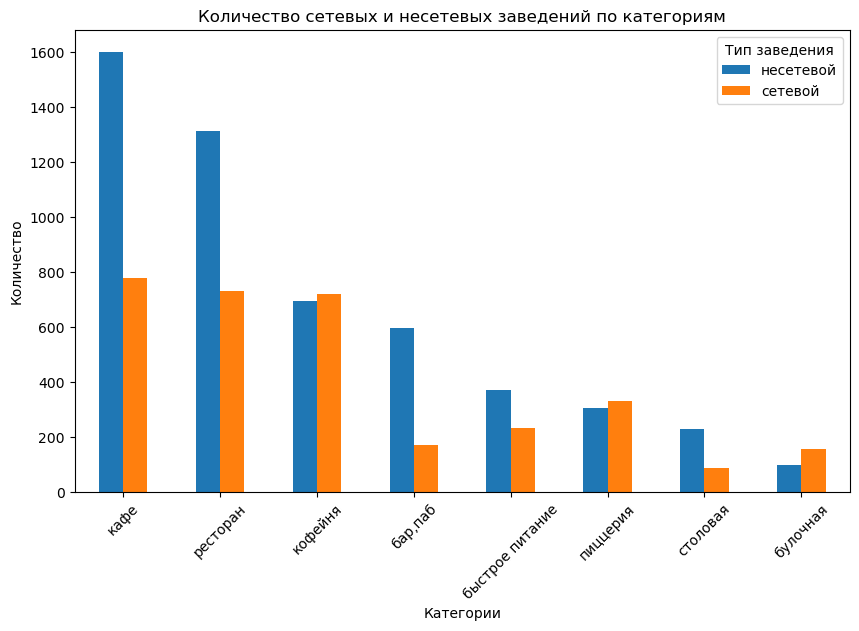

In [34]:
# Создаем визуализацию в абсолютных значеениях
pivot_chain[['несетевой', 'сетевой']].sort_values(by = 'несетевой', ascending=False).plot(kind = 'bar', figsize=(10, 6))

plt.title('Количество сетевых и несетевых заведений по категориям')
plt.ylabel('Количество')
plt.xlabel('Категории')
plt.xticks(rotation = 45)
plt.legend(title='Тип заведения')
plt.show()

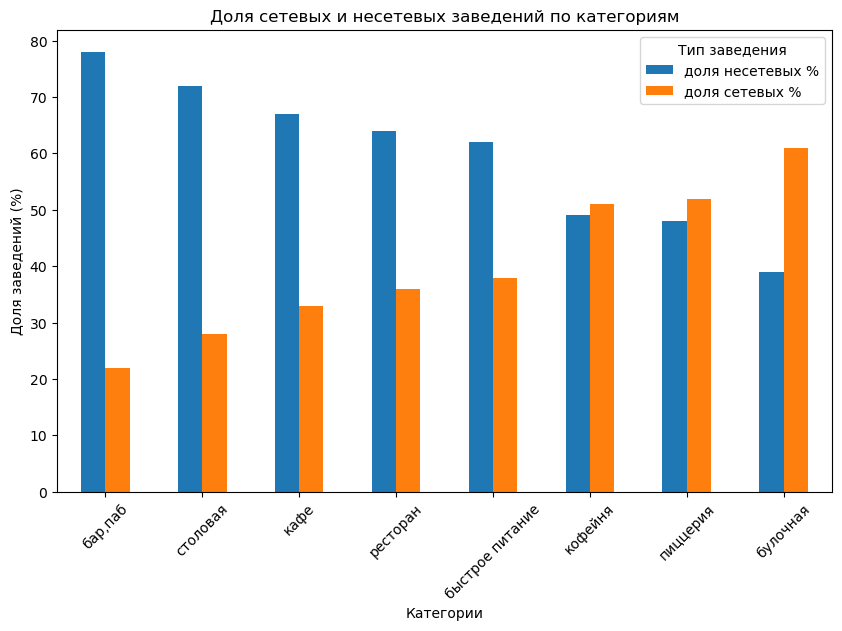

In [35]:
# Создаем визуализацию в относительных значеениях
pivot_chain[['доля несетевых %', 'доля сетевых %']].sort_values(by = 'доля несетевых %', ascending=False).plot(kind = 'bar', figsize=(10, 6))

plt.title('Доля сетевых и несетевых заведений по категориям')
plt.ylabel('Доля заведений (%)')
plt.xlabel('Категории')
plt.xticks(rotation = 45)
plt.legend(title = 'Тип заведения')
plt.show()

**Вывод по распределению несетевых и сетевых заведений**

В целом в исследуемых данных преобладают несетевые заведения. Наибольшее количество как сетевых, так и несетевых объектов приходится на кафе и рестораны.

По доле сетевых заведений лидируют булочные (61%), пиццерии (52%) и кофейни (51%). Вероятно, это связано с тем, что данные форматы легче стандартизировать и масштабировать. В свою очередь, бары, пабы (22%) и столовые (28%) чаще представлены несетевыми заведениями, поскольку их деятельность в большей степени зависит от локальной аудитории и особенностей конкретного заведения.

Таким образом, сетевой формат наиболее характерен для булочных, пиццерий и кофеен.

In [36]:
# Распределение
df['seats'].describe()

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

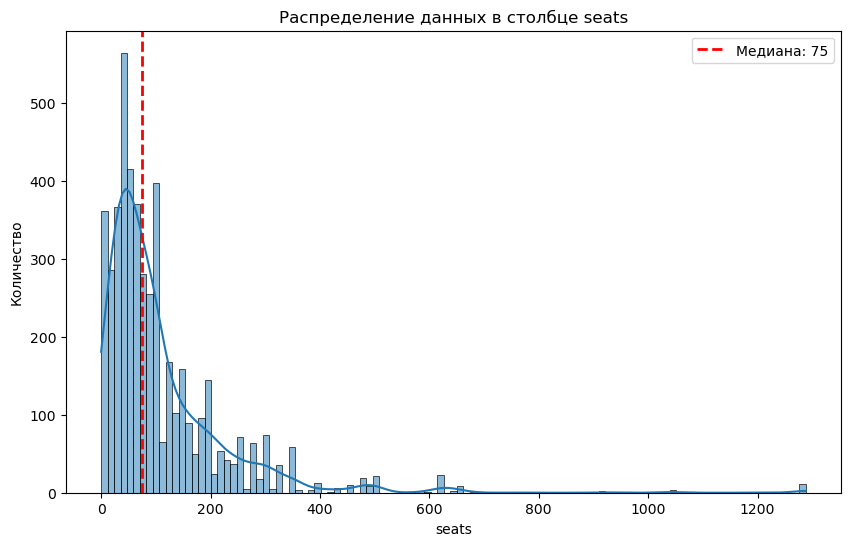

In [37]:
# Создаем график распределеня столбца seats'
plt.figure(figsize=(10, 6))

sns.histplot(data = df, x ='seats', kde=True)

plt.title('Распределение данных в столбце seats')
plt.ylabel('Количество')

# Добавляем медиану
median_seats = df['seats'].median()

plt.axvline(median_seats, color = 'red', linestyle = '--', linewidth = 2, 
            label=f'Медиана: {median_seats:.0f}')

plt.legend()
plt.show()

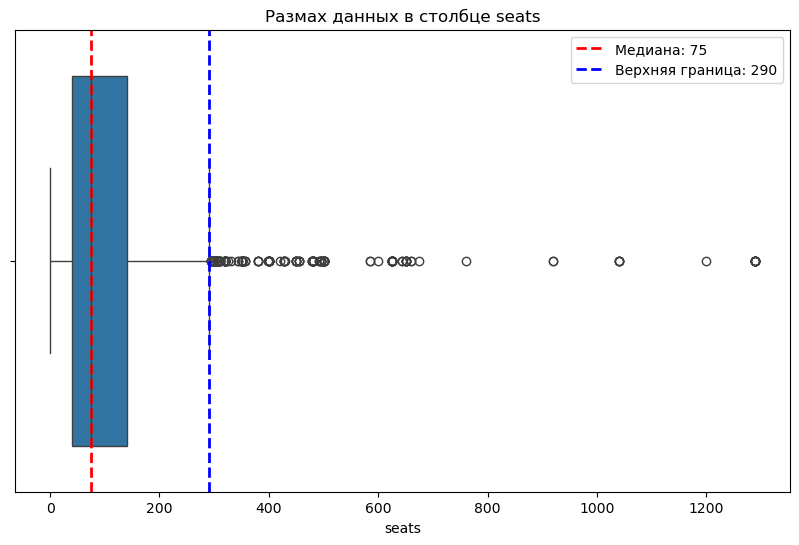

In [38]:
# Создаем диаграму размаха
plt.figure(figsize=(10, 6))

sns.boxplot(data = df, x ='seats')

plt.title('Размах данных в столбце seats')

# Добавляем медиану
plt.axvline(median_seats, color = 'red', linestyle = '--', linewidth = 2, 
            label=f'Медиана: {median_seats:.0f}')

# Добавляем линию верхней границы
IQR = df['seats'].quantile(0.75) - df['seats'].quantile(0.25)
upper_bound = df['seats'].quantile(0.75) + 1.5 * IQR

plt.axvline(upper_bound, color='blue', linestyle='--', linewidth=2, 
            label=f'Верхняя граница: {upper_bound:.0f}')

plt.legend()
plt.show()

In [39]:
# Проверяем данные высше 290 и сортруем по убыванию
df[df['seats'] > 290].sort_values('seats', ascending=False)[['name', 'category', 'seats']].head(10)

,name,category,seats
6838,alternative coffee,кофейня,1288.0
6518,delonixcafe,ресторан,1288.0
6658,гудбар,"бар,паб",1288.0
6690,японская кухня,ресторан,1288.0
6771,точка,кафе,1288.0
6807,loft-cafe академия,кафе,1288.0
6808,яндекс лавка,ресторан,1288.0
6641,one price coffee,кофейня,1288.0
6574,мюнгер,пиццерия,1288.0
6524,ян примус,ресторан,1288.0


In [40]:
# Сортируем по параметру больше 290 и выводим в каких категориях больше встречаются такие значения
df[df['seats'] > 290]['category'].value_counts()

category
ресторан           94
кафе               67
кофейня            55
бар,паб            45
пиццерия           21
быстрое питание    21
столовая            9
булочная            6
Name: count, dtype: int64

In [41]:
# Считаем медиану количества посадочных мест 'seats' по категриям 'category'
df.groupby('category')['seats'].median().sort_values(ascending=False)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

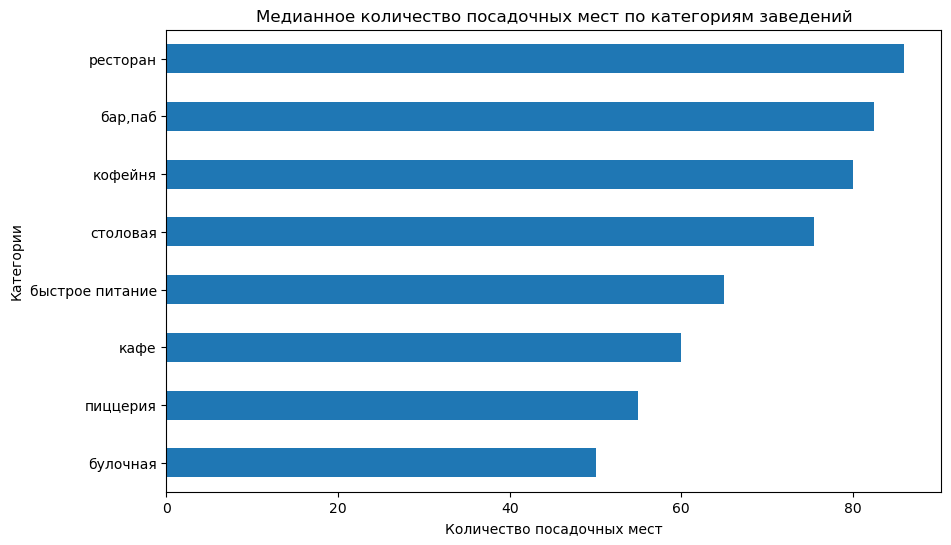

In [42]:
# Создаем визуализацию количества посадочных мест по медиане на каждую категорию
plt.figure(figsize=(10, 6))

df.groupby('category')['seats'].median().sort_values(ascending=True).plot(kind = 'barh')

plt.title('Медианное количество посадочных мест по категориям заведений')
plt.ylabel('Категории')
plt.xlabel('Количество посадочных мест')
plt.show()

**Вывод по анализу посадочных мест в категории**

Анализ количества посадочных мест показал наличие выбросов: по правилу межквартильного размаха они начинаются после 290 мест. Наибольшее число таких заведений относится к следующим категориям:

- ресторан — 94;
- кафе — 67;
- кофейня — 55;
- бар, паб — 45.

Это может быть связано с наличием крупных объектов общественного питания, рассчитанных на большое количество посетителей.

Типичное количество посадочных мест (медиана) по категориям составляет:

- ресторан — 86 мест;
- бар, паб — 83 места;
- кофейня — 80 мест;
- столовая — 75,5 места;
- быстрое питание — 65 мест;
- кафе — 60 мест;
- пиццерия — 55 мест;
- булочная — 50 мест.

Таким образом, наибольшее типичное количество посадочных мест характерно для ресторанов, баров и кофеен, а наименьшее — для булочных и пиццерий.

In [43]:
# Групируем по категрии и находим средний рейтинг
df.groupby('category')['rating'].mean().round(2).sort_values(ascending=False)

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float64

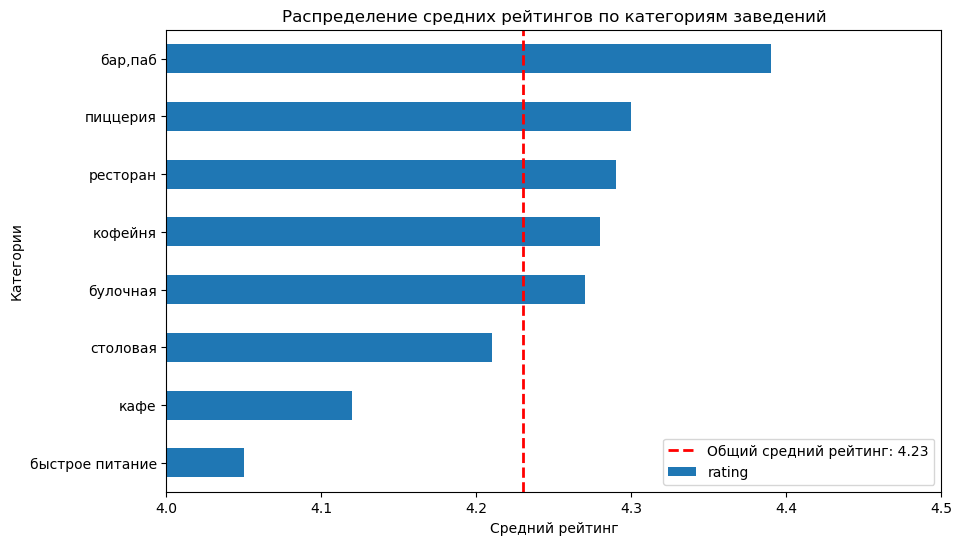

In [44]:
# Создаем визуализацию рейтинга заведений
plt.figure(figsize=(10, 6))

df.groupby('category')['rating'].mean().round(2).sort_values(ascending = True).plot(kind = 'barh')

plt.title('Распределение средних рейтингов по категориям заведений')
plt.ylabel('Категории')
plt.xlabel('Средний рейтинг')

# Добавляем линию общего среднего 
all_rating_mean = df['rating'].mean()
plt.axvline(all_rating_mean, color = 'red', linestyle = '--', linewidth = 2, 
            label=f'Общий средний рейтинг: {all_rating_mean:.2f}')

plt.legend()
# Ограничиваем ось для наглядности
plt.xlim(4, 4.5)
plt.show()

**Вывод по распределению средних рейтингов по категориям заведений**

Средние рейтинги заведений различных категорий находятся в диапазоне от 4,05 до 4,39 балла, что свидетельствует об отсутствии существенных различий между категориями. Наиболее высокий средний рейтинг имеют бары и пабы (4,39), пиццерии (4,30), рестораны (4,29), кофейни (4,28) и булочные (4,27). Их средние оценки превышают общий средний рейтинг по выборке (4,23). Ниже среднего значения находятся столовые (4,21), кафе (4,12) и заведения быстрого питания (4,05). В целом все категории имеют средний рейтинг выше 4 баллов, что говорит о высокой оценке заведений посетителями независимо от формата заведения.

In [45]:
# Загружаем phink
!pip install phik

Defaulting to user installation because normal site-packages is not writeable


In [46]:
# Импортируем phik
from phik import phik_matrix

In [47]:
# Создаем датафрейм для корреляции
df_corr = df[['rating','category','district','chain','seats','price','is_24_7']]

In [48]:
# Выводим датафрейм
df_corr

,rating,category,district,chain,seats,price,is_24_7
0,5.0,кафе,Северный административный округ,0,NaN,нет данных,False
1,4.5,ресторан,Северный административный округ,0,4.0,выше среднего,False
2,4.6,кафе,Северный административный округ,0,45.0,средние,False
3,5.0,кофейня,Северный административный округ,0,NaN,нет данных,False
4,5.0,пиццерия,Северный административный округ,1,148.0,средние,False
...,...,...,...,...,...,...,...
8401,4.4,кафе,Юго-Западный административный округ,0,86.0,нет данных,False
8402,4.8,кафе,Южный административный округ,0,150.0,нет данных,False
8403,3.9,кафе,Юго-Восточный административный округ,0,150.0,нет данных,True
8404,4.2,кафе,Юго-Восточный административный округ,1,150.0,нет данных,True


In [49]:
# Вычисляем корреляционную матрицу с использованием phik
corr_matrix = df_corr.phik_matrix(interval_cols=['rating', 'seats'])

In [50]:
# Выводим матрицу и сортруем
corr_matrix = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by = 'rating', ascending = False)

In [51]:
# Выводим матрицу
corr_matrix

,rating
price,0.281294
district,0.200691
category,0.190003
is_24_7,0.150173
chain,0.108092
seats,0.000000


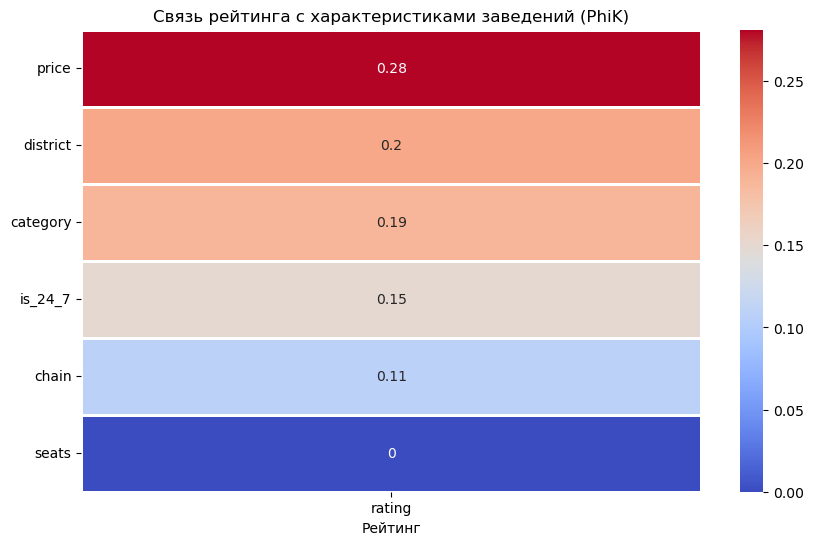

In [52]:
# Строим визуализацию корреляции
plt.figure(figsize=(10, 6))

sns.heatmap(data = corr_matrix, annot = True, linewidths = 1, cmap = 'coolwarm')

plt.title('Связь рейтинга с характеристиками заведений (PhiK)')
plt.xlabel('Рейтинг')
plt.yticks(rotation = 0)
plt.show()

In [53]:
# Группируем данные по 'price' и считаем средний рейтинг
df.groupby('price')['rating'].mean().round(2)

price
высокие          4.44
выше среднего    4.39
нет данных       4.17
низкие           4.17
средние          4.30
Name: rating, dtype: float64

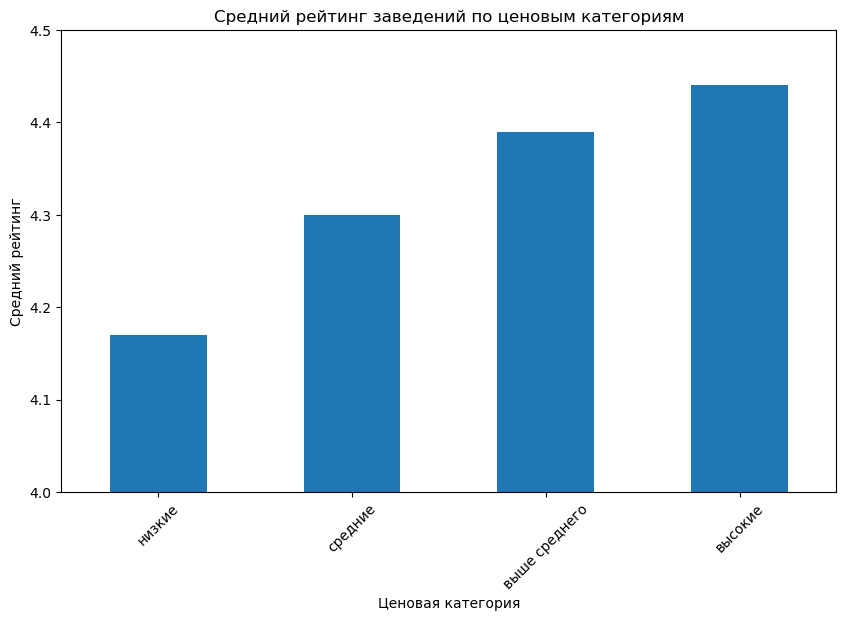

In [54]:
#  Строим столбчатую диграмму, что увидеть как влияют два атрибута друг на друга 'price' и 'rating'
plt.figure(figsize=(10, 6))

# Добаявляем список и делаем переиндексацию
price_order = ['низкие','средние','выше среднего','высокие']

df.groupby('price')['rating'].mean().reindex(price_order).round(2).plot(kind = 'bar')

plt.title('Средний рейтинг заведений по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation = 45)
plt.ylim(4, 4.5)
plt.show()

**Вывод по связь рейтинга с характеристиками заведений**

Для оценки связи рейтинга заведений с различными характеристиками была построена матрица корреляции PhiK. Наиболее сильная связь была обнаружена между рейтингом и ценовой категорией заведения (0,28), однако её нельзя назвать сильной. Дополнительный анализ показал, что средний рейтинг увеличивается вместе с ростом ценовой категории: заведения с высокой ценовой категорией имеют средний рейтинг около 4,44 балла, тогда как заведения с низкой ценовой категорией — около 4,17 балла. При этом количество посадочных мест практически не связано с рейтингом (коэффициент корреляции близок к нулю). В целом ни один из исследованных признаков не демонстрирует сильной зависимости с рейтингом заведений.

In [55]:
# Создаем таблицу по сгруппированным данным по названию и добавляем моду по категриям , агригируем по количеству и рейтингу. 
top_15 = df[df['chain'] == 1].groupby('name').agg({'category': lambda x: x.mode()[0], 'id': 'count','rating': 'mean'}).sort_values(by = 'id', ascending=False).head(15).reset_index()
top_15['rating'] = top_15['rating'].round(2)
top_15

,name,category,id,rating
0,шоколадница,кофейня,120,4.18
1,домино'с пицца,пиццерия,76,4.17
2,додо пицца,пиццерия,74,4.29
3,one price coffee,кофейня,71,4.06
4,яндекс лавка,ресторан,69,3.87
5,cofix,кофейня,65,4.08
6,prime,ресторан,50,4.12
7,хинкальная,кафе,44,4.32
8,кофепорт,кофейня,42,4.15
9,кулинарная лавка братьев караваевых,кафе,39,4.39


In [56]:
# Распределение категорий в топ - 15.
top_15['category'].value_counts()

category
кофейня     5
кафе        4
ресторан    3
пиццерия    2
булочная    1
Name: count, dtype: int64

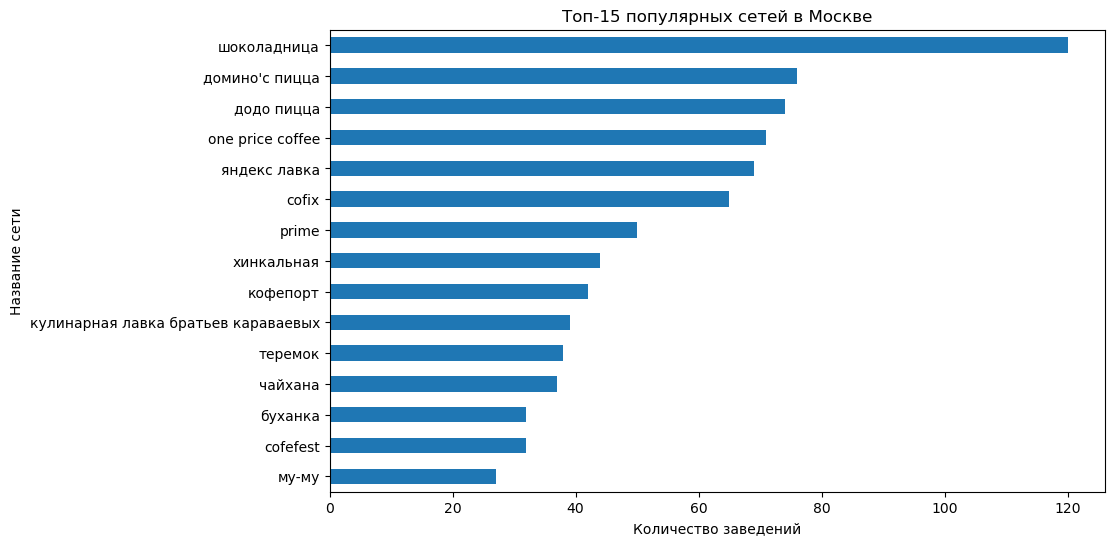

In [57]:
# Создаем график топ-15 популярных сетей в Москве.
top_15.sort_values('id').plot(kind ='barh',x ='name',y ='id',figsize = (10, 6),legend = False)

plt.title('Топ-15 популярных сетей в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.show()

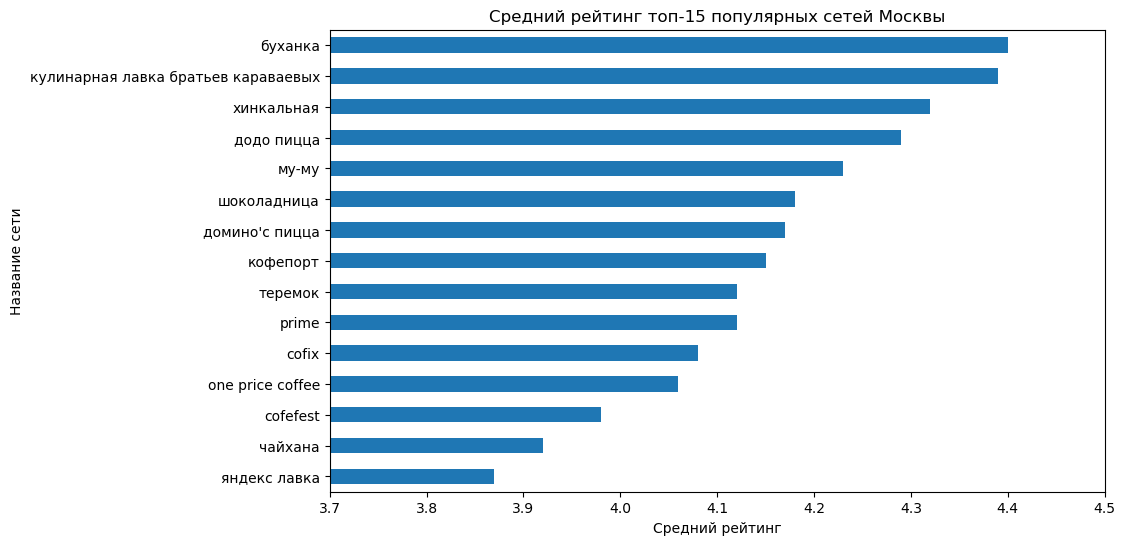

In [58]:
# Создаем график со средним рейтингом заведений

top_15.sort_values('rating').plot(kind ='barh',x ='name',y ='rating',figsize =(10, 6),legend = False)

plt.title('Средний рейтинг топ-15 популярных сетей Москвы')
plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.xlim(3.7, 4.5)
plt.show()

**Вывод по топ-15 популярных сетей в Москве**

Самой популярной сетью в Москве является «Шоколадница» (120 заведений), за ней следуют «Домино'с Пицца» и «Додо Пицца». Среди топ-15 сетей чаще всего встречаются кофейни (5 сетей) и кафе (4 сети), что говорит о высокой популярности этих форматов общепита в Москве. Также в список лидеров вошли рестораны, пиццерии и одна булочная.

In [59]:
# Вариация среднего чего в зависимости от района Москвы.
df.groupby('district')['middle_avg_bill'].mean().round(2).sort_values(ascending=False)

district
Центральный административный округ         1191.06
Западный административный округ            1053.23
Северный административный округ             927.96
Южный административный округ                834.40
Северо-Западный административный округ      822.22
Восточный административный округ            820.63
Юго-Западный административный округ         792.56
Северо-Восточный административный округ     716.61
Юго-Восточный административный округ        654.10
Name: middle_avg_bill, dtype: float64

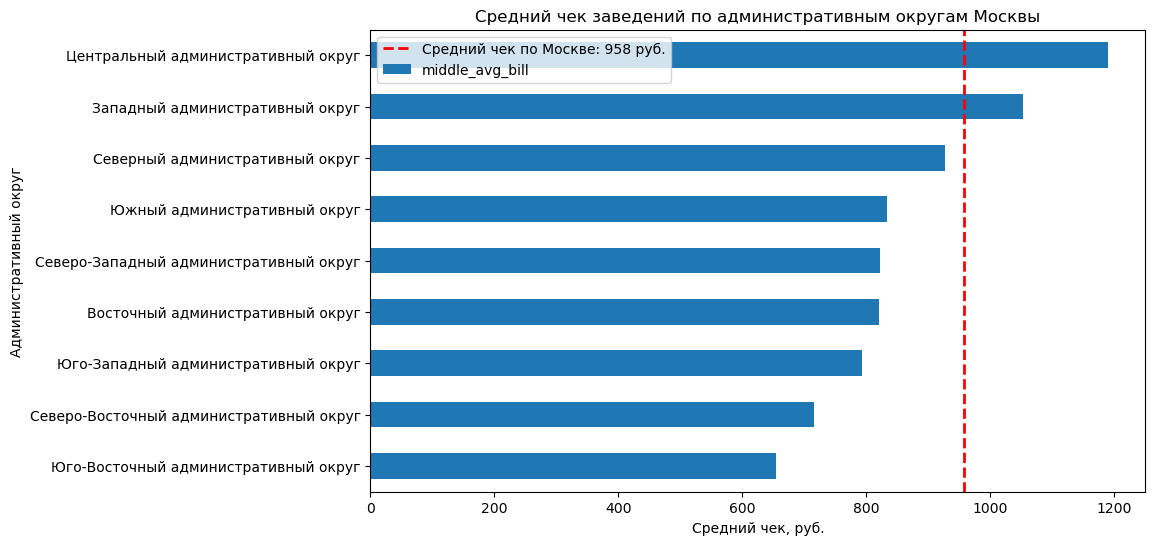

In [60]:
# Создаем диаграмму вариации среденего чека в зависимости от района Москвы.
plt.figure(figsize=(10, 6))

df.groupby('district')['middle_avg_bill'].mean().round(2).sort_values(ascending=True).plot(kind = 'barh')

plt.title('Средний чек заведений по административным округам Москвы')
plt.xlabel('Средний чек, руб.')
plt.ylabel('Административный округ')

#Средний чек по Москве
mean_bill = df['middle_avg_bill'].mean()

plt.axvline(mean_bill, color='red', linestyle='--', linewidth=2,label=f'Средний чек по Москве: {mean_bill:.0f} руб.')

plt.legend()
plt.show()

**Вывод по вариации среднего чека заведения в зависимости от района Москвы.**

Средний чек заведений существенно различается по административным округам Москвы. Наиболее высокий средний чек наблюдается в Центральном административном округе (1191 руб.), который также значительно превышает средний показатель по городу (958 руб.). Второе место занимает Западный административный округ (1053 руб.).

Самые низкие значения среднего чека зафиксированы в Юго-Восточном (654 руб.) и Северо-Восточном административных округах (717 руб.).

В целом результаты показывают, что в центральных округах Москвы средний чек выше, тогда как в более удалённых от центра округах он постепенно снижается. Это может быть связано с более высокой стоимостью аренды и большей концентрацией заведений высокого ценового сегмента в центральной части города.

---

### Промежуточный вывод




Проведённый анализ показал, что рынок общественного питания Москвы достаточно разнообразен, однако основную его часть составляют кафе и рестораны. Значительная концентрация заведений в Центральном административном округе указывает на высокую привлекательность центра города для ведения ресторанного бизнеса.

Несмотря на преобладание несетевых заведений, в отдельных сегментах, таких как кофейни, пиццерии и булочные, сетевой формат занимает сильные позиции. Это может говорить о высокой эффективности масштабирования бизнеса именно в этих категориях.

Средние рейтинги заведений разных категорий отличаются незначительно, а анализ корреляции не выявил сильной связи рейтинга с характеристиками заведений. Следовательно, высокая оценка посетителей зависит не столько от формата заведения, его размера или расположения, сколько от качества сервиса и самого продукта.

Наиболее популярными сетями Москвы являются кофейни, кафе, что дополнительно подтверждает высокий спрос на данные форматы заведений среди посетителей.

Также было установлено, что средний чек напрямую связан с расположением заведения: наиболее высокие цены характерны для центральной части города, тогда как по мере удаления от центра стоимость посещения заведений снижается. Это свидетельствует о различиях в уровне спроса, стоимости аренды и платёжеспособности аудитории в разных районах Москвы.


# 4. Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В рамках исследования была проведена предварительная обработка данных: устранены пропуски и дубликаты, приведены к корректному виду названия категорий и заведений, а также подготовлены данные для дальнейшего анализа. После этого был выполнен исследовательский анализ рынка общественного питания Москвы. Были изучены структура рынка по категориям заведений, их территориальное распределение, уровень сетевизации, количество посадочных мест, рейтинги, ценовые характеристики и наиболее популярные сети города. Также была исследована связь рейтинга заведений с различными характеристиками и проанализированы различия среднего чека по административным округам.

### Основные выводы

Исследование показало, что основу рынка общественного питания Москвы составляют кафе и рестораны. Значительная часть заведений сосредоточена в Центральном административном округе, что подтверждает высокую привлекательность центральной части города для размещения бизнеса.

Большинство заведений являются несетевыми, однако в сегментах кофеен, пиццерий и булочных сетевой формат развит значительно сильнее. Это свидетельствует о том, что данные категории лучше поддаются масштабированию и стандартизации бизнес-процессов.

Средние рейтинги заведений различных категорий находятся на схожем уровне, а анализ корреляции показал отсутствие сильной зависимости рейтинга от формата заведения, его размера, расположения или других исследуемых характеристик. Следовательно, высокий рейтинг определяется прежде всего качеством обслуживания, ассортиментом и общим клиентским опытом.

Среди сетевых заведений лидирующие позиции занимают кофейни, кафе и пиццерии. Наиболее популярной сетью является «Шоколадница». Анализ топ-15 наиболее распространённых сетей Москвы показал, что в их структуре преобладают кофейни (5 сетей), кафе (4 сети) и рестораны (3 сети). Также в список вошли пиццерии (2 сети) и одна булочная. Это свидетельствует о высокой востребованности данных форматов и подтверждает сильные позиции сетевых кофеен и кафе на московском рынке общественного питания.

Также было установлено, что наиболее высокий средний чек характерен для заведений, расположенных в центральной части города. По мере удаления от центра средний чек снижается, что указывает на различия в покупательной способности аудитории и стоимости ведения бизнеса в разных районах Москвы.

### Рекомендации

Для открытия нового заведения инвесторам стоит рассмотреть форматы кафе или кофейни, поскольку именно эти категории являются наиболее востребованными на рынке и успешно представлены как среди отдельных заведений, так и среди крупных сетей.

При выборе локации следует учитывать компромисс между потенциальной выручкой и затратами. Центральный административный округ обеспечивает более высокий средний чек и высокий поток посетителей, однако требует значительно больших вложений. Более удалённые районы могут стать привлекательной альтернативой благодаря меньшим операционным расходам и более низкому уровню конкуренции.

Поскольку сильной связи между рейтингом и формальными характеристиками заведения не выявлено, особое внимание рекомендуется уделить качеству сервиса, ассортименту и формированию положительного клиентского опыта. Именно эти факторы, вероятно, оказывают наибольшее влияние на восприятие заведения посетителями и его долгосрочную конкурентоспособность.
